<a href="https://colab.research.google.com/github/manan36chauhan/data_science_project/blob/First-init/mnist_bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Load Data
Explanation: The MNIST dataset in the CSV has columns: id (unique identifier), class (digit label 0-9), and pixel1 to pixel784 (28x28 image flattened, values 0-255). We use Pandas to read the CSV and inspect it to understand its structure.

In [2]:
import pandas as pd

# Load the dataset (adjust path as needed, e.g., 'mnist.csv')
df = pd.read_csv('mnist.csv')

# Quick inspection
print("Dataset shape:", df.shape)
print("\nFirst few rows:\n", df.head())
print("\nColumn names:\n", df.columns)
print("\nData types:\n", df.dtypes)

Dataset shape: (4000, 786)

First few rows:
       id  class  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  \
0  31953      5       0       0       0       0       0       0       0   
1  34452      8       0       0       0       0       0       0       0   
2  60897      5       0       0       0       0       0       0       0   
3  36953      0       0       0       0       0       0       0       0   
4   1981      3       0       0       0       0       0       0       0   

   pixel8  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0         0         0         0   
3       0  ...         0         0         0         0         0         0   
4       0  ...         0         0         0         0         0         0   

   pixel781  pixel782  pixel783  pi

2. Explore (EDA)
Goal: Perform Exploratory Data Analysis (EDA) to understand the dataset’s characteristics, check for issues, and visualize the data.
Explanation: EDA helps identify patterns, anomalies, or preprocessing needs. For MNIST, we check class distribution, pixel value ranges, and visualize some digit images to confirm the data represents 28x28 grayscale images.


Class distribution:
 class
0    376
1    486
2    390
3    417
4    369
5    363
6    391
7    426
8    416
9    366
Name: count, dtype: int64
Pixel Value stats:        pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  pixel9  \
count  4000.0  4000.0  4000.0  4000.0  4000.0  4000.0  4000.0  4000.0  4000.0   
mean      0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
std       0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
min       0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
25%       0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
50%       0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
75%       0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
max       0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   

       pixel10  ...     pixel775     pixel776     pixel777     pixel778  \
count   4000.0  ...  4000.000000

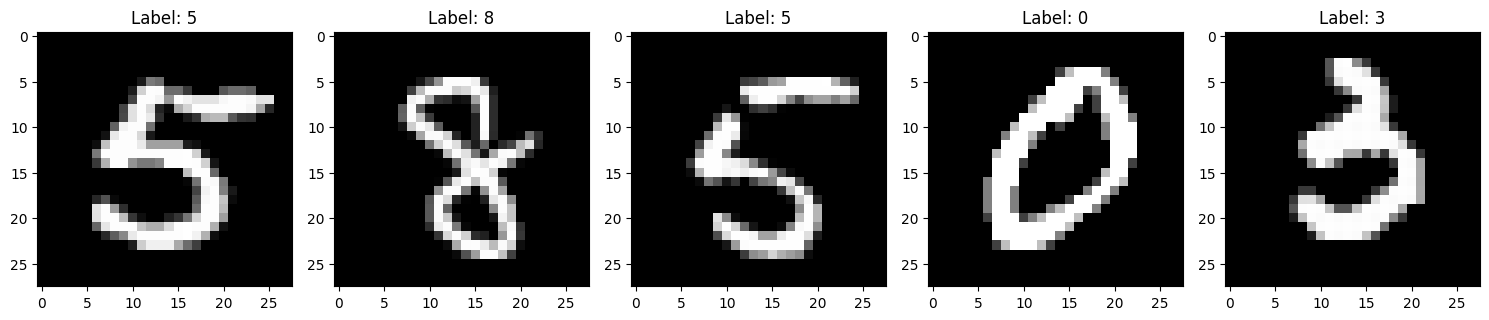


Missing values:
 0


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check class distribution
class_counts = df['class'].value_counts().sort_index()
print("\nClass distribution:\n", class_counts)
print("Pixel Value stats:", df.iloc[:, 2:].describe())

# visualize a few images

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, ax in enumerate(axes):
    img = df.iloc[i, 2:].values.reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Label: {df.iloc[i, 1]}")
plt.tight_layout()
plt.show()

# Check for missing values
print("\nMissing values:\n", df.isna().sum().sum())

3. Handle Missing Values
Goal: Check for and address any missing values in the dataset.
Explanation: Missing values can break machine learning models. For MNIST, we expect no missing values since it’s a curated dataset, but we verify. If any exist, we could impute (e.g., mean/median for pixels) or drop rows

In [7]:
# Check for missing values
missing = df.isna().sum()
print("Missing values per column:\n", missing[missing > 0])

# If missing values exist (unlikely), impute with 0 (background) for pixels
if df.isna().sum().sum() > 0:
    df.iloc[:, 2:] = df.iloc[:, 2:].fillna(0)  # Fill pixel columns with 0
    print("Missing pixel values filled with 0")

Missing values per column:
 Series([], dtype: int64)


4. Feature Engineering
Goal: Create or modify features to improve model performance.
Explanation: The MNIST pixels (784 features) are already suitable for Naive Bayes, as they directly represent the image. However, we can consider:

Binarization: Convert pixels to 0/1 (e.g., >0 becomes 1) for Bernoulli Naive Bayes.
Dimensionality reduction: Use PCA to reduce 784 features (optional, not needed for Naive Bayes).
Edge detection: Extract edges (complex, unnecessary here).

For simplicity, we’ll skip complex feature engineering but note binarization as an option for later (Bernoulli NB).

In [8]:
# No new features needed, but check pixel ranges
print("Pixel min:", df.iloc[:, 2:].min().min())
print("Pixel max:", df.iloc[:, 2:].max().max())

Pixel min: 0
Pixel max: 255


5. Train/Test Split
Goal: Split the dataset into training and test sets to evaluate model generalization.
Explanation: We split the data (e.g., 80% train, 20% test) to train the model on one subset and test on unseen data. We drop id (irrelevant) and separate class (labels) from pixels (features).

In [9]:
from sklearn.model_selection import train_test_split
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Features (pixels) and labels (class)
X = df.drop(['id', 'class'], axis=1)
y = df['class']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training features shape:", X_train.shape)
print("Test features shape:", X_test.shape)
print("Training labels shape:", y_train.shape)
print("Test labels shape:", y_test.shape)

Training features shape: (3200, 784)
Test features shape: (800, 784)
Training labels shape: (3200,)
Test labels shape: (800,)


6. Preprocessing
Scaling: Normalize pixel values to [0,1] (divide by 255) for Gaussian NB to stabilize numerical computations.

In [10]:
from sklearn.preprocessing import StandardScaler, Binarizer

# Scaling: Normalize pixels to [0,1]
X_train_scaled = X_train / 255.0
X_test_scaled = X_test / 255.0

# Optional: Binarization for Bernoulli NB (threshold at 0.5 after scaling)
binarizer = Binarizer(threshold=0.5)
X_train_binary = binarizer.fit_transform(X_train_scaled)
X_test_binary = binarizer.transform(X_test_scaled)
print("Scaled training data min:", X_train_scaled.min().min())
print("Scaled training data max:", X_train_scaled.max().max())
print("Binary training data unique values:", np.unique(X_train_binary))

Scaled training data min: 0.0
Scaled training data max: 1.0
Binary training data unique values: [0. 1.]


7. Train Naive Bayes
Goal: Train a Gaussian Naive Bayes model (and optionally Bernoulli NB) on the preprocessed data.
Explanation: Gaussian NB assumes features follow a normal distribution, suitable for scaled pixels. Bernoulli NB assumes binary features, so we use binarized data.

In [11]:
from sklearn.naive_bayes import GaussianNB, BernoulliNB

# Gaussian Naive Bayes
gnb = GaussianNB(var_smoothing=1e-9)  # Default hyperparam
gnb.fit(X_train_scaled, y_train)

# Optional: Bernoulli Naive Bayes
bnb = BernoulliNB()
bnb.fit(X_train_binary, y_train)

print("Gaussian NB trained.")
print("Bernoulli NB trained.")

Gaussian NB trained.
Bernoulli NB trained.


8. Evaluate
Goal: Assess model performance on the test set using accuracy and other metrics.
Explanation: Accuracy is the primary metric for MNIST (fraction of correct predictions). We can also check the confusion matrix and classification report for detailed performance.

In [12]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predictions
gnb_predictions = gnb.predict(X_test_scaled)
bnb_predictions = bnb.predict(X_test_binary)

# Accuracy
gnb_accuracy = accuracy_score(y_test, gnb_predictions)
bnb_accuracy = accuracy_score(y_test, bnb_predictions)
print(f"Gaussian NB Test Accuracy: {gnb_accuracy * 100:.2f}%")
print(f"Bernoulli NB Test Accuracy: {bnb_accuracy * 100:.2f}%")

# Detailed metrics for Gaussian NB
print("\nGaussian NB Classification Report:\n", classification_report(y_test, gnb_predictions))
print("\nGaussian NB Confusion Matrix:\n", confusion_matrix(y_test, gnb_predictions))

Gaussian NB Test Accuracy: 63.88%
Bernoulli NB Test Accuracy: 82.62%

Gaussian NB Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.94      0.82        70
           1       0.66      0.95      0.78       100
           2       0.69      0.25      0.36        73
           3       0.88      0.60      0.72        86
           4       0.74      0.39      0.51        80
           5       0.38      0.08      0.13        64
           6       0.61      0.90      0.73        90
           7       0.98      0.67      0.80        67
           8       0.44      0.50      0.47        94
           9       0.50      0.93      0.65        76

    accuracy                           0.64       800
   macro avg       0.66      0.62      0.60       800
weighted avg       0.66      0.64      0.61       800


Gaussian NB Confusion Matrix:
 [[66  0  0  0  1  0  3  0  0  0]
 [ 0 95  0  0  0  2  2  0  1  0]
 [ 7  4 18  3  0  1 28  0 12  0]
 [ 4

9. Tune Hyperparameters
Goal: Optimize the model by tuning hyperparameters.
Explanation: Gaussian NB has one key hyperparameter: var_smoothing. Bernoulli NB has alpha (smoothing) and binarize (threshold). We use grid search to find the best values.

In [13]:
from sklearn.model_selection import GridSearchCV

# Gaussian NB tuning
gnb_param_grid = {'var_smoothing': [1e-11, 1e-9, 1e-7, 1e-5]}
gnb_grid = GridSearchCV(GaussianNB(), gnb_param_grid, cv=5, scoring='accuracy')
gnb_grid.fit(X_train_scaled, y_train)

# Bernoulli NB tuning
bnb_param_grid = {'alpha': [0.1, 0.5, 1.0], 'binarize': [0.3, 0.5, 0.7]}
bnb_grid = GridSearchCV(BernoulliNB(), bnb_param_grid, cv=5, scoring='accuracy')
bnb_grid.fit(X_train_binary, y_train)

print("Best Gaussian NB params:", gnb_grid.best_params_)
print("Best Gaussian NB accuracy:", gnb_grid.best_score_ * 100)
print("Best Bernoulli NB params:", bnb_grid.best_params_)
print("Best Bernoulli NB accuracy:", bnb_grid.best_score_ * 100)

# Evaluate best models on test set
best_gnb = gnb_grid.best_estimator_
best_bnb = bnb_grid.best_estimator_
print("Best Gaussian NB test accuracy:", accuracy_score(y_test, best_gnb.predict(X_test_scaled)) * 100)
print("Best Bernoulli NB test accuracy:", accuracy_score(y_test, best_bnb.predict(X_test_binary)) * 100)

Best Gaussian NB params: {'var_smoothing': 1e-05}
Best Gaussian NB accuracy: 69.0625
Best Bernoulli NB params: {'alpha': 0.1, 'binarize': 0.3}
Best Bernoulli NB accuracy: 83.4375
Best Gaussian NB test accuracy: 71.625
Best Bernoulli NB test accuracy: 82.875


10. Inspect Coefficients
Goal: Examine model parameters to understand its behavior.
Explanation: In Gaussian NB, “coefficients” are the means (theta_) and variances (var_) of features per class. For Bernoulli NB, it’s log probabilities of features (feature_log_prob_). We visualize the mean image for each digit to see what the model learned.

Gaussian NB class priors: [0.095625  0.120625  0.0990625 0.1034375 0.0903125 0.0934375 0.0940625
 0.1121875 0.100625  0.090625 ]
Gaussian NB means shape: (10, 784)


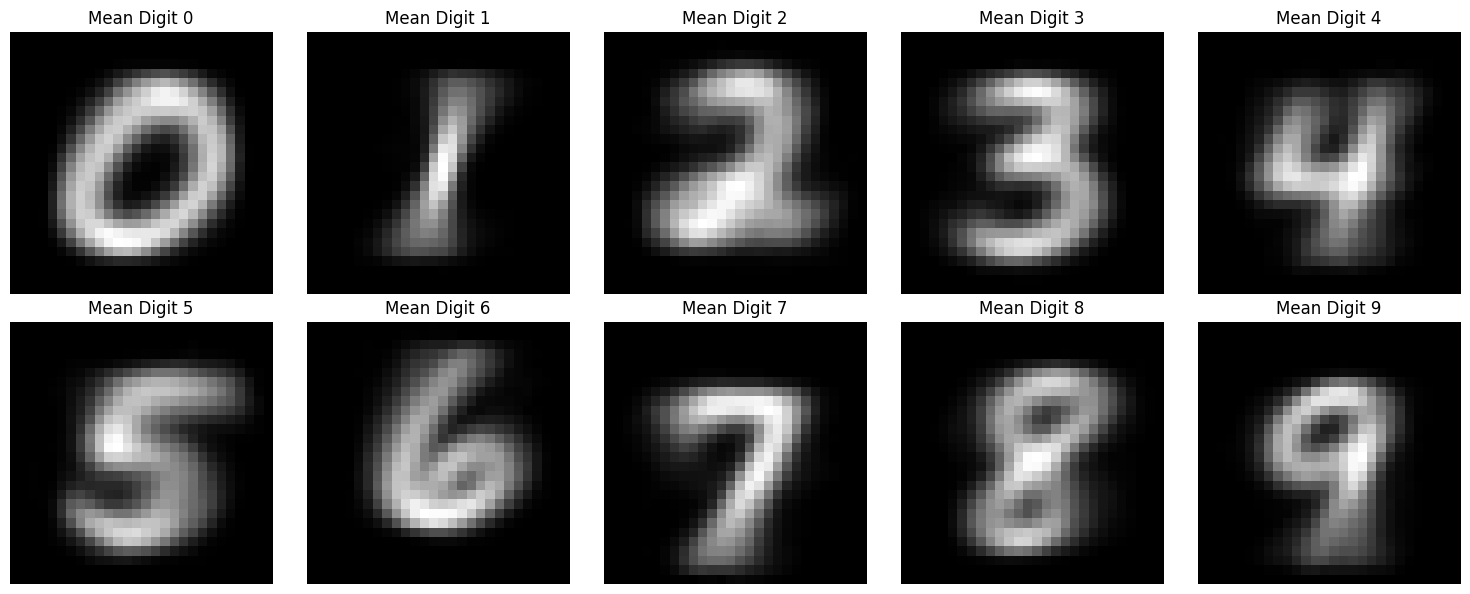

Bernoulli NB feature log probs shape: (10, 784)


In [14]:
# Gaussian NB coefficients
print("Gaussian NB class priors:", gnb.class_prior_)
print("Gaussian NB means shape:", gnb.theta_.shape)  # (10, 784)

# Visualize mean image for each digit
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flatten()):
    mean_img = gnb.theta_[i].reshape(28, 28)
    ax.imshow(mean_img, cmap='gray')
    ax.set_title(f"Mean Digit {i}")
    ax.axis('off')
plt.tight_layout()
plt.show()

# Bernoulli NB log probabilities
print("Bernoulli NB feature log probs shape:", bnb.feature_log_prob_.shape)